This notebook accompagnies the lecture on 

***Reasoning and decision-making models***

Author: Daniel Straub

In [66]:
import numpy as np
import matplotlib.pyplot as plt

**Part 1: Expected utility theory**

a) Find your own utility function

b) Find optimal decisions for you

1a) To find your own utility functions, we consider a series of hypothetical bets. Try to consider the questions as realistically as possible.
Every time, you bet on the color of a ball drawn from a bag (white or red). 

White: you win $𝑦_{win}$. 

Red: you lose $𝑦_{loss}$.

The percentage of white balls, i.e., the probability of winning, is $p$.

$𝑝_ind$ is the value of $𝑝$ for which you are indifferent between the two decision alternatives; for values $𝑝>𝑝_{ind}$ you take the bet for values $𝑝<{𝑝_ind}$ you do not take the bet.

Insert your values of $p_{ind}$ in the following. (All wins and losses are in Euro)


In [67]:
p_ind = np.zeros(7)
# y_win = 1000, y_loss = 1000
p_ind[0] = 0.55
# y_win = 5000, y_loss = 1000
p_ind[1] = 0.25
# y_win = 5000, y_loss = 5000
p_ind[2] = 0.65
# y_win = 20'000, y_loss = 5000
p_ind[3] = 0.35
# y_win = 20'000, y_loss = 20'000
p_ind[4] = 0.75
# y_win = 50'000, y_loss = 20'000
p_ind[5] = 0.6


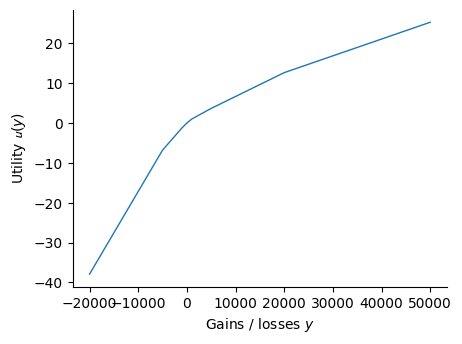

In [68]:
# Evaluate your utility function u:

# Values of wins/losses (Python uses 0-based indexing, MATLAB used 1-based)
y = np.array([-20000, -5000, -1000, 0, 1000, 5000, 20000, 50000])
#     index:      0       1      2   3    4     5      6      7

# Bets: 
y_win = np.array([4, 5, 5, 6, 6, 7]) 
y_loss = np.array([2, 2, 1, 1, 0, 0]) 

# Utility array:
u = np.full(8, np.nan)
u[3] = 0   # utility at y = 0
u[4] = 1   # utility at y = 1000

# Solve for the remaining utility values from the indifference points,
# alternating between the loss and win side
for i in range(6):
    if (i + 1) % 2 == 1:  # odd step: solve for the loss side
        u[y_loss[i]] = -u[y_win[i]] * p_ind[i] / (1 - p_ind[i])
    else:                  # even step: solve for the win side
        u[y_win[i]] = -u[y_loss[i]] * (1 - p_ind[i]) / p_ind[i]

# --- Plot ---
wid, hei = 8, 6  # centimeters
fig, ax = plt.subplots(figsize=(1.5 * wid / 2.54, 1.5 * hei / 2.54))  # cm -> inches

yy = np.arange(-20e3, 50e3 + 1e3, 1e3)
uu = np.interp(yy, y, u)  

ax.plot(yy, uu, linewidth=1)
ax.set_title("")
ax.set_xlabel(r'Gains / losses $y$')
ax.set_ylabel(r'Utility $\mathcal{u}(y)$')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()  
plt.show()

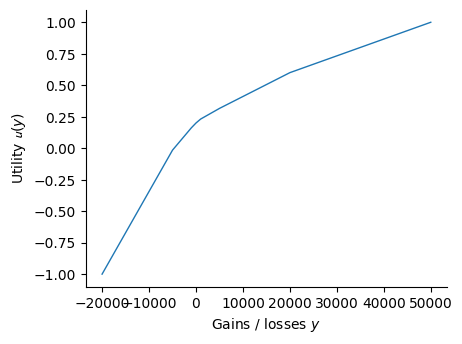

In [69]:
# Normalize utility function so u passes through -1 at y[0] and +1 at y[-1] ---
# Utility is only defined up to a positive affine transform, so we can rescale/shift freely: u_norm = a*u + b, solved from the two endpoints.
a = 2.0 / (u[-1] - u[0])
b = -1.0 - a * u[0]
u = a * u + b   # now u[0] == -1 and u[-1] == +1

# Build a reusable utility function via linear interpolation:
utility = interp1d(y, u, kind="linear", fill_value="extrapolate")

# Plot the normalized utility function:
fig, ax = plt.subplots(figsize=(1.5 * wid / 2.54, 1.5 * hei / 2.54))  # cm -> inches

yy = np.arange(-20e3, 50e3 + 1e3, 1e3)
uu = np.interp(yy, y, u)  

ax.plot(yy, uu, linewidth=1)
ax.set_title("")
ax.set_xlabel(r'Gains / losses $y$')
ax.set_ylabel(r'Utility $\mathcal{u}(y)$')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()  
plt.savefig("utility_function.png", dpi=300)
plt.show()


b) Now evaluate whether or not to purchase the insurance

Expected utility with insurance: 0.1923
Expected utility without insurance: 0.1936
Not buying insurance is the better choice.


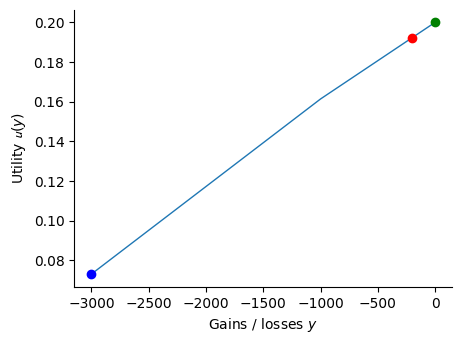

In [70]:
# Decision setting:
CL = 3e3 # cost of loss of bicycle or car
CP = 2e2 # cost of insurance premium
pL = 0.05 # probability of loss

EU_insurance = utility(-CP)
EU_noInsurance = utility(0) * (1 - pL) + utility(-CL) * pL

print(f"Expected utility with insurance: {EU_insurance:.4f}")
print(f"Expected utility without insurance: {EU_noInsurance:.4f}")
if EU_insurance > EU_noInsurance:
    print("Buying insurance is the better choice.") 
else:
    print("Not buying insurance is the better choice.")
    
# Plot the zoomed in utility function:
fig, ax = plt.subplots(figsize=(1.5 * wid / 2.54, 1.5 * hei / 2.54))  # cm -> inches

yy = np.arange(-CL, 0 + 1e2, 1e2)

ax.plot(yy, utility(yy), linewidth=1)
ax.plot(-CL, utility(-CL), 'bo', label='Cost of loss')
ax.plot(-CP, utility(-CP), 'ro', label='Insurance premium')
ax.plot(0, utility(0), 'go', label='No loss')
ax.set_title("")
ax.set_xlabel(r'Gains / losses $y$')
ax.set_ylabel(r'Utility $\mathcal{u}(y)$')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()  
plt.show()